# Distance to Nearest Land Cost Data
This workbook integrates the land cover grid coordinate extraction with our cKDTree spatial index approach. We first construct the base `xarray` dataset grid from satellite data, map nationwide land cost statistics to its cells using a spatial index, and save the optimized file directly to your Output folder.

In [1]:
import geopandas as gpd
import pandas as pd
import xarray as xr
import numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import os
try:
    import rioxarray
except ImportError:
    print("⚠️ rioxarray not found. Please run '!pip install rioxarray' as it is required for masking the sea/boundaries.")

### 1. Construct Target xarray Dataset
We extract the exact bounding coordinates for Thailand and slice the satellite land cover data to establish our base coordinate grid.

In [2]:
### Efficient forest distance with cKDTree ###
thailandmap = gpd.read_file('Data\\tha_admbnda_adm1_rtsd_20220121\\tha_admbnda_adm1_rtsd_20220121.shp').to_crs(epsg=4326)
min_lon, min_lat, max_lon, max_lat = thailandmap.total_bounds

xr_landuse = xr.open_dataset("Data//dataset-satellite-land-cover//C3S-LC-L4-LCCS-Map-300m-P1Y-2022-v2.1.1.nc")
lat_vals = xr_landuse['lat']
lon_vals = xr_landuse['lon']
if lat_vals[0] > lat_vals[-1]:
    lat_slice = slice(max_lat, min_lat)
else:
    lat_slice = slice(min_lat, max_lat)
if lon_vals[0] > lon_vals[-1]:
    lon_slice = slice(max_lon, min_lon)
else:
    lon_slice = slice(min_lon, max_lon)

xr_landuse = xr_landuse.sel(lat=lat_slice, lon=lon_slice)
xr_landuse = xr_landuse.reindex(lat=xr_landuse.lat[::-1])
xr_landuse = xr_landuse.sel(time='2022-01-01').drop_vars('time')
lccs_resolution = 300  # meters

# Initialize the base xarray dataset from the landuse grid coordinates
xr_landcost = xr.Dataset(
    coords={
        "lat": xr_landuse.lat,
        "lon": xr_landuse.lon,
    }
)

print("Initialized target xarray dataset:")
display(xr_landcost)

Initialized target xarray dataset:


<xarray.Dataset> Size: 67kB
Dimensions:  (lat: 5346, lon: 2985)
Coordinates:
  * lat      (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon      (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    *empty*

### 2. Load the Land Cost Shapefile & CSV
We load the shapes from the `.shp` file and merge them with the attribute data from the paired `.csv` file.

In [3]:
# Load the nationwide stats shapefile and paired CSV
shapefile_path = 'Data\\L7018_nationwide_stats.shp'
csv_path = 'Data\\L7018_nationwide_stats.csv'

try:
    # Read geometries from the .shp file (will just have a 'geometry' column)
    gdf_geom = gpd.read_file(shapefile_path)
    
    # Read attribute data from the .csv file
    df_attrs = pd.read_csv(csv_path)
    
    # Combine them into a single GeoDataFrame assuming a 1:1 row correspondence
    gdf_land = gpd.GeoDataFrame(df_attrs, geometry=gdf_geom.geometry)
    
    # Be transparent about the columns available
    print("Available columns in the combined dataset:", gdf_land.columns.tolist())
    
    # Create a dropdown to make the cost metric easily selectable
    cost_selector = widgets.Dropdown(
        options=['AVG_PRICE', 'MED_PRICE', 'MAX_PRICE', 'MIN_PRICE'],
        value='AVG_PRICE',
        description='Cost Metric:',
        disabled=False,
    )
    print("\n👇 Select the land cost metric to map to the xarray dataset:")
    display(cost_selector)
        
except Exception as e:
    print(f"Error loading files: {e}")
    print("Please make sure both the .shp/.shx files and the .csv file are available.")


Available columns in the combined dataset: ['NAME', 'LAYER', 'AREA', 'PERIMETER', 'SHEET50K_', 'SHEET50K_I', 'SHEET50K', 'SHEET_GRP', 'SHEET_ORD', 'SHEET_T', 'SHEET_E', 'LABEL_NO', 'AVG_PRICE', 'MED_PRICE', 'MAX_PRICE', 'MIN_PRICE', 'geometry']

👇 Select the land cost metric to map to the xarray dataset:


Dropdown(description='Cost Metric:', options=('AVG_PRICE', 'MED_PRICE', 'MAX_PRICE', 'MIN_PRICE'), value='AVG_…

### 2.1 Handle Outliers in AVG_PRICE
We detect upper outliers in the AVG_PRICE column using the Interquartile Range (IQR) method and set them to null, as high-cost areas may not be suitable for development.

In [4]:
# Handle upper outliers in AVG_PRICE using IQR method
if 'gdf_land' in locals() and 'AVG_PRICE' in gdf_land.columns:
    # Ensure AVG_PRICE is numeric
    gdf_land['AVG_PRICE'] = pd.to_numeric(gdf_land['AVG_PRICE'], errors='coerce')
    
    # Drop NaN values for outlier calculation
    prices = gdf_land['AVG_PRICE'].dropna()
    
    if len(prices) > 0:
        Q1 = prices.quantile(0.25)
        Q3 = prices.quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identify upper outliers
        outliers_upper = gdf_land[gdf_land['AVG_PRICE'] > upper_bound]
        print(f"Detected {len(outliers_upper)} upper outliers in AVG_PRICE (values > {upper_bound:.2f}).")
        
        # Set upper outliers to NaN
        gdf_land['AVG_PRICE'] = gdf_land['AVG_PRICE'].where(gdf_land['AVG_PRICE'] <= upper_bound, np.nan)
        print(f"Omitted {len(outliers_upper)} upper outliers by setting them to NaN.")
    else:
        print("No valid AVG_PRICE data found for outlier detection.")
else:
    print("gdf_land not loaded or AVG_PRICE column not found.")

Detected 104 upper outliers in AVG_PRICE (values > 2274.58).
Omitted 104 upper outliers by setting them to NaN.


### 4. Prepare Data for Spatial Indexing (cKDTree)
We extract valid coordinates, ensure they match our `EPSG:4326` lat/lon grid, and extract centroids for the KDTree.

In [5]:
# Ensure we are working with points for the KDTree and aligning CRS
if 'gdf_land' in locals():
    gdf_points = gdf_land.copy()
    
    # --- Robust CRS Alignment to fix potential NaN masking errors --- 
    if gdf_points.crs is None:
        # If there was no .prj file, check if coords are large (meters vs degrees)
        # Use total_bounds [minx, miny, maxx, maxy] to safely check coordinate extents
        minx, miny, maxx, maxy = gdf_points.total_bounds
        if maxx > 180:
            print("⚠️ Large coordinate values detected with missing CRS. Assuming UTM Zone 47N (EPSG:32647).")
            gdf_points.set_crs(epsg=32647, inplace=True)
        else:
            gdf_points.set_crs(epsg=4326, inplace=True)
            
    # Explicitly convert to standard geographic coords to match the xarray grid
    gdf_points = gdf_points.to_crs(epsg=4326)
    
    if gdf_points.geometry.geom_type.iloc[0] in ['Polygon', 'MultiPolygon']:
        print("Converting polygons to centroids for spatial indexing...")
        # Suppress UserWarning about centroid calculation on geographic CRS
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            gdf_points['geometry'] = gdf_points.geometry.centroid


⚠️ Large coordinate values detected with missing CRS. Assuming UTM Zone 47N (EPSG:32647).
Converting polygons to centroids for spatial indexing...


### 5. Query the Tree and Assign Values to xarray
We dynamically clean the data for the selected column (dropping nulls), build the KDTree, query it, assign the results, strictly mask out the ocean/neighboring countries, and finally normalize the values with an inverted score.

In [6]:
if 'gdf_points' in locals() and 'xr_landcost' in locals() and 'thailandmap' in locals():
    # Dynamically fetch the cost column selected by the user
    cost_column = cost_selector.value
    print(f"Preparing and cleaning data for '{cost_column}'...")
    
    # --- 1. Prevent NaN propagation and deal with Nulls ---
    # Force numeric conversion and drop missing/empty values BEFORE building the tree
    valid_points = gdf_points.copy()
    valid_points[cost_column] = pd.to_numeric(valid_points[cost_column], errors='coerce')
    valid_points = valid_points.dropna(subset=[cost_column])
    # Omit 0.0 values, as they typically represent un-surveyed or "null" land cost data
    valid_points = valid_points[valid_points[cost_column] > 0]
    
    if len(valid_points) == 0:
        print(f"❌ ERROR: No valid numeric data found in column '{cost_column}'.")
    else:
        # Build the KDTree using only points with genuine, valid data
        tree_coords = np.vstack([valid_points.geometry.x, valid_points.geometry.y]).T
        print(f"Building KDTree with {len(tree_coords)} valid points...")
        tree = cKDTree(tree_coords)

        # Extract 2D meshgrids directly from the xarray dataset coordinates
        lon_grid, lat_grid = np.meshgrid(xr_landcost.lon.values, xr_landcost.lat.values)
        
        # Flatten the grid to pass to the KDTree query
        target_coords = np.vstack([lon_grid.ravel(), lat_grid.ravel()]).T
        
        print(f"Querying KDTree to assign '{cost_column}' to {len(target_coords)} cells...")
        distances, nearest_indices = tree.query(target_coords, k=1)
        
        try:
            # Extract the valid land cost values
            nearest_cost_values = valid_points.iloc[nearest_indices][cost_column].values
            
            # Assign the reshaped data directly into the xarray.Dataset
            var_name = f"land_cost_{cost_column.lower()}"
            xr_landcost[var_name] = (["lat", "lon"], nearest_cost_values.reshape(lon_grid.shape))
            xr_landcost["distance_to_nearest_cost_pt"] = (["lat", "lon"], distances.reshape(lon_grid.shape))
            
            # --- 2. Masking the sea and areas outside Thailand ---
            print("\nMasking out the sea and areas outside Thailand...")
            try:
                import rioxarray
                # Set coordinate references for rioxarray
                xr_landcost.rio.write_crs("epsg:4326", inplace=True)
                xr_landcost.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
                
                # Clip data to Thailand's borders (assigns NaN to anything outside)
                xr_landcost = xr_landcost.rio.clip(thailandmap.geometry, thailandmap.crs, drop=False)
                print("✅ Mask successfully applied!")
            except ImportError:
                print("⚠️ 'rioxarray' library not found. Skipping spatial mask. (Install with: !pip install rioxarray)")

            # --- 3. INVERTED Normalize to 0-3 Range using True Max-Min --- 
            print(f"\nNormalizing mapped values to an INVERTED 0-3 scale using dataset {cost_column} bounds...")
            # Get absolute min/max from the original valid dataset to ensure true global bounds
            c_min = valid_points[cost_column].min()
            c_max = valid_points[cost_column].max()
            
            if c_max > c_min:
                norm_var_name = f"{var_name}_norm"
                # Inverted Max-Min Normalization: Lower Price = Closer to 3.0, Higher Price = Closer to 0.0
                xr_landcost[norm_var_name] = ((c_max - xr_landcost[var_name]) / (c_max - c_min)) * 3.0
                # Assign 0 to areas with no data (including high-cost outlier areas)
                xr_landcost[norm_var_name] = xr_landcost[norm_var_name].fillna(0)
                print(f"✅ Inverted Normalization complete! (Data Min: {c_min} -> Score: 3.0 | Data Max: {c_max} -> Score: 0.0)")
                print(f"   -> Added '{norm_var_name}' to dataset.")
            else:
                print("⚠️ Min and Max are identical, skipping normalization.")

            print("\n✅ Data processing complete. Updated xarray dataset:")
            display(xr_landcost)
            
        except KeyError:
            print(f"\nERROR: Column '{cost_column}' extraction failed.")

Preparing and cleaning data for 'AVG_PRICE'...
Building KDTree with 649 valid points...
Querying KDTree to assign 'AVG_PRICE' to 15957810 cells...

Masking out the sea and areas outside Thailand...
✅ Mask successfully applied!

Normalizing mapped values to an INVERTED 0-3 scale using dataset AVG_PRICE bounds...
✅ Inverted Normalization complete! (Data Min: 28.61111111111111 -> Score: 3.0 | Data Max: 2272.3845327604727 -> Score: 0.0)
   -> Added 'land_cost_avg_price_norm' to dataset.

✅ Data processing complete. Updated xarray dataset:


<xarray.Dataset> Size: 383MB
Dimensions:                      (lat: 5346, lon: 2985)
Coordinates:
  * lat                          (lat) float64 43kB 5.615 5.618 ... 20.46 20.46
  * lon                          (lon) float64 24kB 97.35 97.35 ... 105.6 105.6
    spatial_ref                  int32 4B 0
Data variables:
    land_cost_avg_price          (lat, lon) float64 128MB nan nan ... nan nan
    distance_to_nearest_cost_pt  (lat, lon) float64 128MB nan nan ... nan nan
    land_cost_avg_price_norm     (lat, lon) float64 128MB 0.0 0.0 ... 0.0 0.0

### 6. Visualize and Save the Output

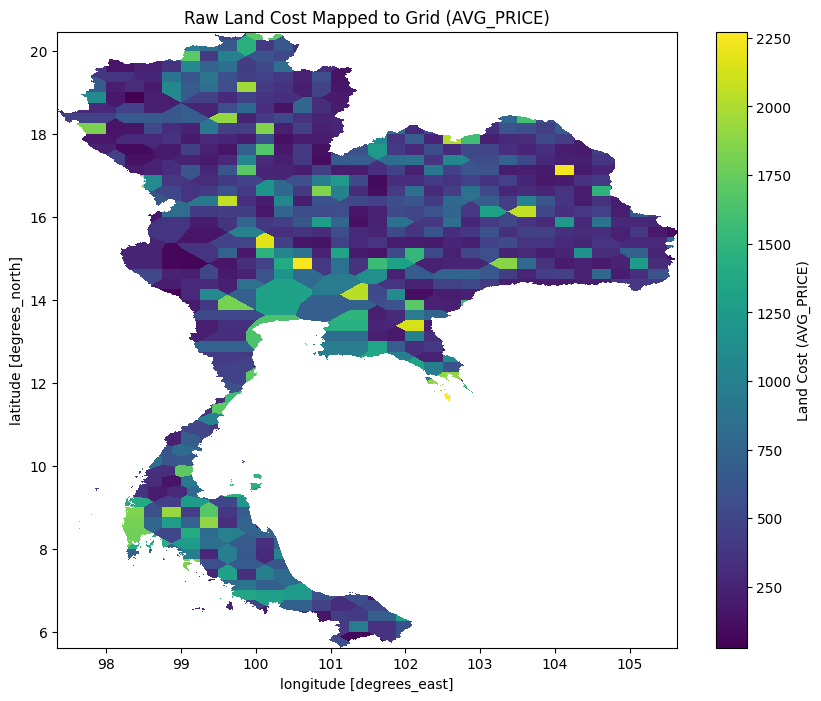

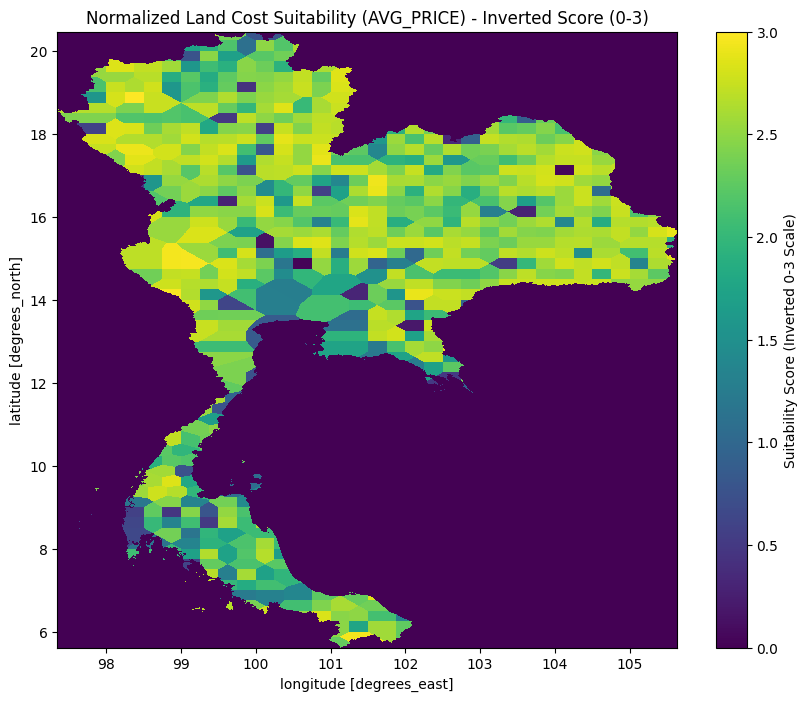

Saved Output\xr_SI_LandCost.nc
<xarray.Dataset> Size: 383MB
Dimensions:                      (lat: 5346, lon: 2985)
Coordinates:
  * lat                          (lat) float64 43kB 5.615 5.618 ... 20.46 20.46
  * lon                          (lon) float64 24kB 97.35 97.35 ... 105.6 105.6
    spatial_ref                  int32 4B 0
Data variables:
    land_cost_avg_price          (lat, lon) float64 128MB nan nan ... nan nan
    distance_to_nearest_cost_pt  (lat, lon) float64 128MB nan nan ... nan nan
    land_cost_avg_price_norm     (lat, lon) float64 128MB 0.0 0.0 ... 0.0 0.0


In [7]:
if 'xr_landcost' in locals() and hasattr(cost_selector, 'value'):
    cost_column = cost_selector.value
    var_name = f"land_cost_{cost_column.lower()}"
    norm_var_name = f"{var_name}_norm"
    
    # Plot raw land cost data
    if var_name in xr_landcost:
        plt.figure(figsize=(10, 8))
        xr_landcost[var_name].plot(cmap='viridis', cbar_kwargs={'label': f'Land Cost ({cost_column})'})
        plt.title(f'Raw Land Cost Mapped to Grid ({cost_column})')
        plt.show()
    
    # Plot normalized suitability score
    if norm_var_name in xr_landcost:
        plt.figure(figsize=(10, 8))
        xr_landcost[norm_var_name].plot(cmap='viridis', cbar_kwargs={'label': 'Suitability Score (Inverted 0-3 Scale)'})
        plt.title(f'Normalized Land Cost Suitability ({cost_column}) - Inverted Score (0-3)')
        plt.show()

# Ensure the output directory exists
os.makedirs('Output', exist_ok=True)

# Save optimized dataset directly
output_path = 'Output\\xr_SI_LandCost.nc'
if 'xr_landcost' in locals():
    xr_landcost.to_netcdf(path=output_path)
    print('Saved', output_path)
    print(xr_landcost)
